# Metody Stochastyczne w Uczeniu Maszynowym
## Piotr Błaszczyk
## Lab 1

#### importy

In [5]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Generate Synthetic Data

Generate a synthetic dataset with a known linear relationship. Create 100 data points with a single feature, using a true weight of 2 and a bias of 5, plus a small amount of Gaussian noise. This will create data that follows the relationship $y=2x+5+\epsilon$ where $\epsilon$ is random noise.
Set a random seed for reproducibility. Your feature matrix X should have shape (100, 1) and your target vector y should have shape (100,).

In [6]:
np.random.seed(69)

N = 100

X = np.random.rand(N, 1) * 10

epsilon = np.random.randn(N)

y = 2 * X.flatten() + 5 + epsilon

### 2. Prepare the Data

To include the bias term in our weight vector, add a column of 1s to your feature matrix X. This allows us to represent both the bias and feature weight in a single vector, simplifying our implementation.

In [7]:
X_b = np.hstack([np.ones((N, 1)), X])

# sanity check
print(X_b.shape)  # (100, 2)
print(X_b[:5])

(100, 2)
[[1.         2.96249162]
 [1.         8.09067716]
 [1.         3.50252525]
 [1.         7.89409256]
 [1.         5.61348976]]


### 3. Initialize Parameters

Initialize your weight vector with zeros. Since we have one feature plus the bias term, your weight vector should have shape (2,), where the first element represents the bias and the second represents the feature weight.

In [8]:
w = np.zeros(2)
print(w)

[0. 0.]


### 4. Implement Gradient Descent
Compute the gradient (formula is provided in the introduction) and update weights.

In [9]:
def compute_gradient(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    N = len(y)
    y_pred = X @ w
    error = y_pred - y
    grad = (2 / N) * X.T @ error
    return grad

In [12]:
grad = compute_gradient(X_b, y, w)
print(grad)

[ -28.45364896 -157.3148249 ]


### 5. Run the Training Loop
Put it all together to train the model. Track values of the loss function during this process. 

In [13]:
def compute_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

In [17]:
lr = 0.01
epochs = 1000

w = np.zeros(2)
loss_history = []

for epoch in range(epochs):
    y_pred = X_b @ w
    loss = np.mean((y_pred - y) ** 2)
    grad = (2 / len(y)) * X_b.T @ (y_pred - y)

    w -= lr * grad
    loss_history.append(loss)

### 6. Check Your Results
After training, compare your weights to the true ones. Plot the data and compare fitted model with the ground truth line.

In [18]:
true_w = np.array([5, 2])

print("Learned weights:", w)
print("True weights:", true_w)
print("Difference:", w - true_w)

Learned weights: [4.93432278 2.03340672]
True weights: [5 2]
Difference: [-0.06567722  0.03340672]


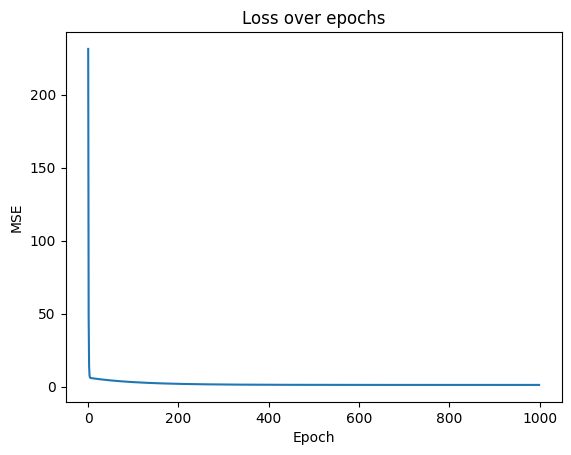

In [19]:
plt.plot(loss_history)
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

#### no widać, mega szybko sie nauczył, 1000 epok to overkill. Wygląda jakby 100 starczyło

### 7. Experiment with Learning Rate
The learning rate α controls how big of a step we take during each iteration of gradient descent. Try training your model with different learning rates: $\alpha \in [10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}]$. For each value:
- Plot the loss curve (loss vs. epoch)
- Record the final weights and final loss
- Observe how quickly (or slowly) the model converges

In [20]:
lrs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
epochs = 150 # w porównaniu tego co było wczęsniej, bo widac że przy 1000 to wszystko idealnie "zkonwerguje"

results = {}

for lr in lrs:
    w = np.zeros(2)
    loss_history = []

    for epoch in range(epochs):
        y_pred = X_b @ w
        loss = np.mean((y_pred - y) ** 2)
        grad = (2 / len(y)) * X_b.T @ (y_pred - y)

        w -= lr * grad
        loss_history.append(loss)

    results[lr] = {
        "w": w,
        "loss_history": loss_history,
        "final_loss": loss_history[-1]
    }

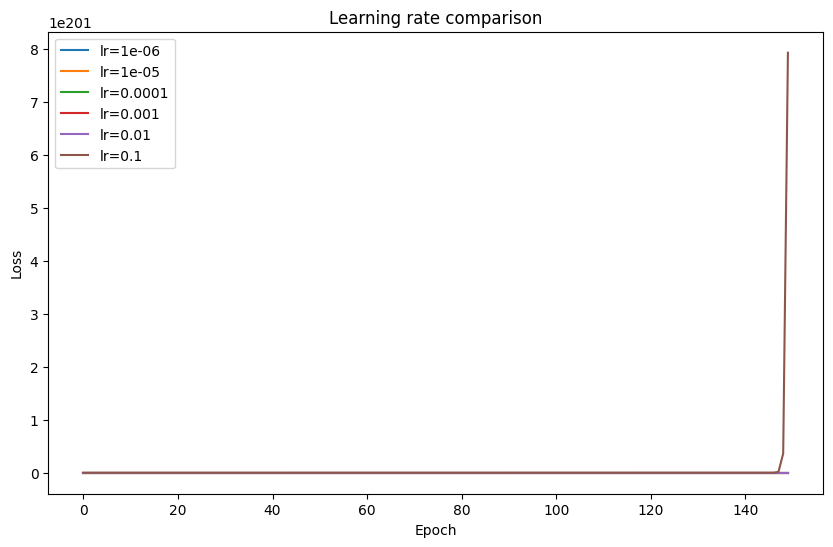

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for lr in lrs:
    plt.plot(results[lr]["loss_history"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning rate comparison")
plt.legend()
plt.show()

#### No dla α = 0.1 explodowało i przy okazji popsuło wykres, że dla innych nic nie widać. Zrobie kolejną iteracje, ale bez α = 0.1 oraz mniej epok

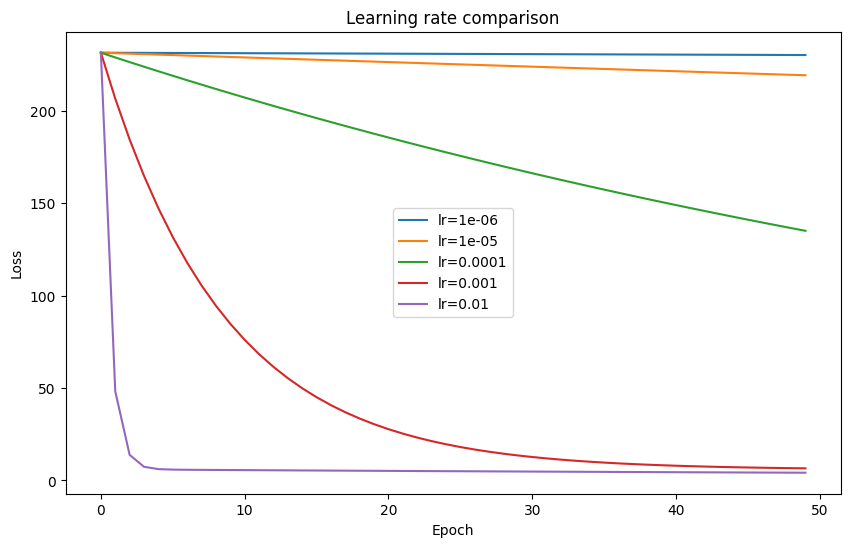

In [22]:
lrs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2] # bez 0.1
epochs = 50 # mniej epok

results = {}

for lr in lrs:
    w = np.zeros(2)
    loss_history = []

    for epoch in range(epochs):
        y_pred = X_b @ w
        loss = np.mean((y_pred - y) ** 2)
        grad = (2 / len(y)) * X_b.T @ (y_pred - y)

        w -= lr * grad
        loss_history.append(loss)

    results[lr] = {
        "w": w,
        "loss_history": loss_history,
        "final_loss": loss_history[-1]
    }


plt.figure(figsize=(10, 6))

for lr in lrs:
    plt.plot(results[lr]["loss_history"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning rate comparison")
plt.legend()
plt.show()

#### No i tutaj już coś fajnego widać. jak widąc, najlepsze okazało się α = 0.01. Więc jak widac, nie jest oczywiste, że większe lub mniejsz α będzie zawsze lepsze

### 8. Explore Training Duration
Set `num_epochs` to larger values like 100 or 1000 and observe the training process:
- Does the loss continue to decrease throughout training, or does it plateau?
- At what point does the model effectively converge?
- Plot the loss curve for the extended training and identify where diminishing returns begin
- Calculate how close your final weights are to the true weights after different numbers of epochs

This exercise helps you understand when to stop training to avoid wasting computational resources.

#### biore α = 0.001 ( zielone na wykrsie ) bo 0.01 i 0.001 szybko zconverguje i będzie nuda

In [30]:
epochs_list = [10, 50, 100, 500, 1000]

lr = 0.0001 # biore to ( zielone na wykrsie ) bo 0.01 i 0.001 szybko zconverguje i będzie nuda

results_epochs = {}

for epochs in epochs_list:
    w = np.zeros(2)
    loss_history = []

    for num_epoch in range(epochs):
        y_pred = X_b @ w
        loss = np.mean((y_pred - y) ** 2)
        grad = (2 / len(y)) * X_b.T @ (y_pred - y)

        w -= lr * grad
        loss_history.append(loss)

    results_epochs[epochs] = {
        "w": w,
        "loss_history": loss_history,
        "final_loss": loss_history[-1]
    }

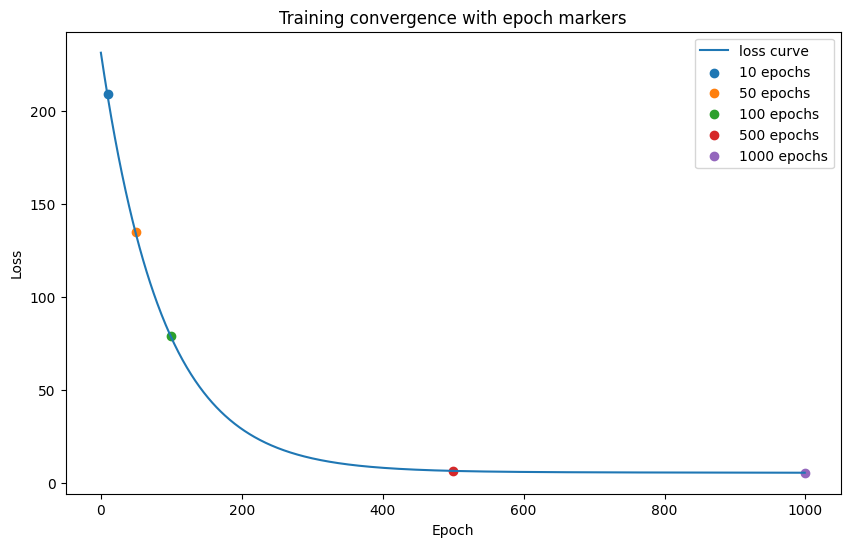

In [32]:
epochs_list = [10, 50, 100, 500, 1000]

plt.figure(figsize=(10, 6))

plt.plot(loss_history, label="loss curve")

for e in epochs_list:
    plt.scatter(e, loss_history[e-1], label=f"{e} epochs")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training convergence with epoch markers")
plt.legend()
plt.show()

In [33]:
epochs_list = [10, 50, 100, 500, 1000]

print("Epochs | Final MSE")
print("-------------------")

for epochs in epochs_list:
    mse = results_epochs[epochs]["final_loss"]
    print(f"{epochs:6} | {mse:.4f}")

Epochs | Final MSE
-------------------
    10 | 209.3425
    50 | 134.9934
   100 | 79.0204
   500 | 6.6027
  1000 | 5.6140


#### No wiadomo, że gdybyśmy wzieli najlepsze α ( 0.01 ) to jeszcze szybciej byśmy się uwinęli, ale tutaj tak dla około 600 już jest git

### 9. Visualize the Loss Landscape
Create a visualization of the loss function across different weight values:
- Generate a grid of weight values
- Calculate the loss at each point in this grid
- Create a contour plot showing the "landscape" of the loss function
- Mark your initial weights, final weights, and the true weights on this plot

This visualization will help you understand the shape of the objective function you're optimizing and how gradient descent navigates this landscape to find the minimum.

In [35]:
# szybki trening
lr = 0.01
epochs = 500

w = np.zeros(2)

for _ in range(epochs):
    y_pred = X_b @ w
    grad = (2 / len(y)) * X_b.T @ (y_pred - y)
    w -= lr * grad

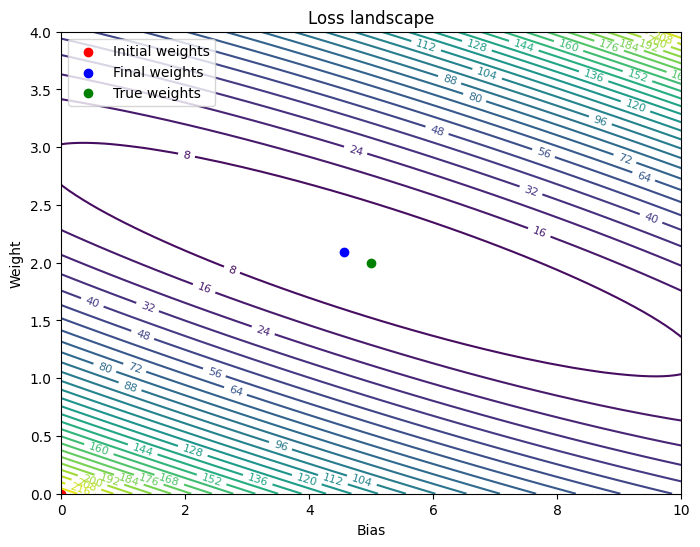

In [36]:
b_vals = np.linspace(0, 10, 100)
w_vals = np.linspace(0, 4, 100)

B, W = np.meshgrid(b_vals, w_vals)
Z = np.zeros_like(B)

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        w_tmp = np.array([B[i, j], W[i, j]])
        y_pred = X_b @ w_tmp
        Z[i, j] = np.mean((y_pred - y) ** 2)

initial_w = np.array([0, 0])
true_w = np.array([5, 2])

plt.figure(figsize=(8, 6))
contours = plt.contour(B, W, Z, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

plt.scatter(initial_w[0], initial_w[1], color="red", label="Initial weights")
plt.scatter(w[0], w[1], color="blue", label="Final weights")
plt.scatter(true_w[0], true_w[1], color="green", label="True weights")

plt.xlabel("Bias")
plt.ylabel("Weight")
plt.title("Loss landscape")
plt.legend()
plt.show()

#### no fajnie, efekt spodziewany. Niebieska kropka blisko zielonej, czerwona gdzieś tam w rogach, więc model się dobrze uczy

### 10. Analytical Solution
For linear regression, the closed-form solution is 

$$\widehat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Compare the parameters and final MSE you get via gradient descent with those from the analytical solution. Are they similar?

In [39]:
# szybki trening ( teraz na bogato )
lr = 0.01
epochs = 3000

w = np.zeros(2)

for _ in range(epochs):
    y_pred = X_b @ w
    grad = (2 / len(y)) * X_b.T @ (y_pred - y)
    w -= lr * grad

In [40]:
y_pred_gd = X_b @ w
mse_gd = np.mean((y_pred_gd - y) ** 2)

w_analytical = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
y_pred_analytical = X_b @ w_analytical
mse_analytical = np.mean((y_pred_analytical - y) ** 2)

print("Gradient Descent weights:", w)
print("Gradient Descent MSE:", mse_gd)
print()

print("Analytical weights:", w_analytical)
print("Analytical MSE:", mse_analytical)
print()

print("Difference in weights:", w - w_analytical)
print("Difference in MSE:", mse_gd - mse_analytical)

Gradient Descent weights: [4.97223581 2.02708174]
Gradient Descent MSE: 1.0839867852980796

Analytical weights: [4.97223849 2.0270813 ]
Analytical MSE: 1.0839867852963174

Difference in weights: [-2.68149875e-06  4.47350526e-07]
Difference in MSE: 1.7621459846850485e-12


#### no wyniki defacto identyczne, analityczne ciut lepiej, ale i tak różnica jest śmiesznie małą ( teraz dałem na bogato 3000 epok + najlesze α ). Wiadomo, że do aproksymacji funkcji iniowej lepiej użyć wzoru do explicte funkcji linowych, ale gradient descent o wiele bardziej wszechstrony